In [6]:
from sklearn.linear_model import LogisticRegression

from src.preprocessing import load_data, prep_pipeline
data=load_data()
df = data["EEG_Eye_State_Classification"]

In [7]:
X=df.drop(['eyeDetection'], axis =1 ).copy()
y=df['eyeDetection'].copy()

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
prep = prep_pipeline()
X_train_prep = prep.fit_transform(X_train)
X_test_prep = prep.transform(X_test)

In [9]:
from src.preprocessing import window_eeg

X_windows, y_windows = window_eeg(df, target='eyeDetection', window_size=64)

print("Windowed X shape:", X_windows.shape)
print("Windowed y shape:", y_windows.shape)


Windowed X shape: (234, 896)
Windowed y shape: (234,)


In [10]:
#PCA dim reductionality -> Rips->PH->feature extraction->classifier

In [11]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
X_reduced = pca.fit_transform(X_windows)

print("Original shape:", X_windows.shape)
print("Reduced shape:", X_reduced.shape)

Original shape: (234, 896)
Reduced shape: (234, 10)


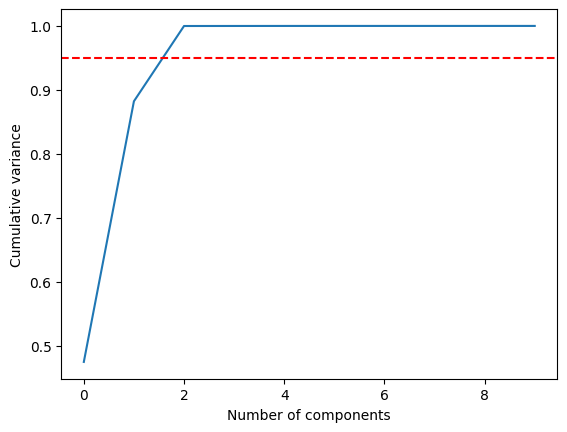

In [12]:
import numpy as np

X_pca = pca.fit_transform(X_windows)
import matplotlib.pyplot as plt

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.axhline(0.95, color='red', linestyle='--')  # 95% variance line
plt.ylabel("Cumulative variance")
plt.show()

In [13]:
#TEST LR on PCA'd window X, this is force using 10 features instead of 3 as would above w/ 95% var
from src.models import baseline
from sklearn.metrics import classification_report, confusion_matrix
lr = baseline()

X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(X_windows, y_windows, test_size = 0.2, random_state = 42, stratify = y_windows)
X_w_train_prep = prep.fit_transform(X_w_train)
X_w_test_prep = prep.transform(X_w_test)
lr.fit(X_w_train_prep, y_w_train)
y_w_pred = lr.predict(X_w_test_prep)
print(
classification_report(y_w_test, y_w_pred),
confusion_matrix(y_w_test, y_w_pred))

              precision    recall  f1-score   support

           0       0.67      0.69      0.68        26
           1       0.60      0.57      0.59        21

    accuracy                           0.64        47
   macro avg       0.63      0.63      0.63        47
weighted avg       0.64      0.64      0.64        47
 [[18  8]
 [ 9 12]]


In [14]:
from src.models import tree
dt = tree(n_pca_components=10, max_depth=4, min_samples_leaf=2)

dt.fit(X_w_train_prep, y_w_train)
y_w_pred = dt.predict(X_w_test_prep)
print(
classification_report(y_w_test, y_w_pred),
confusion_matrix(y_w_test, y_w_pred))

              precision    recall  f1-score   support

           0       0.73      0.85      0.79        26
           1       0.76      0.62      0.68        21

    accuracy                           0.74        47
   macro avg       0.75      0.73      0.73        47
weighted avg       0.75      0.74      0.74        47
 [[22  4]
 [ 8 13]]


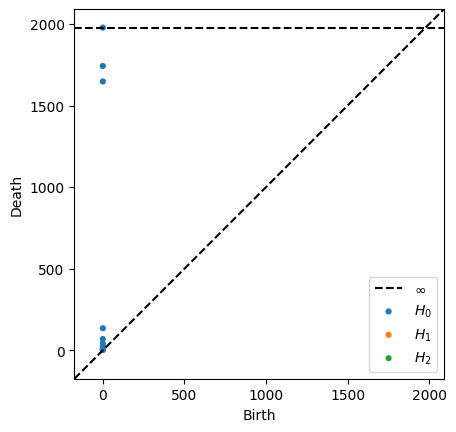

In [15]:
from src.preprocessing import load_data, window_eeg
from src.features import pca_transform, compute_persistence, vectorize_diagrams, plot_example_diagram

data_dict = load_data()
df = data_dict["EEG_Eye_State_Classification"]

X_windows, y_windows = window_eeg(df, target='eyeDetection', window_size=64)

X_pca, pca_model = pca_transform(X_windows, n_components=10)

diagrams = compute_persistence(X_pca, maxdim=2)

# 5️⃣ Vectorize diagrams for ML input
X_features = vectorize_diagrams(diagrams)

# 6️⃣ Optional: visualize first window's diagram
plot_example_diagram(diagrams[0])

# Now X_features and y_windows are ready for ML models


In [25]:
X_features = np.nan_to_num(X_features, nan=0.0, posinf=1e6, neginf=-1e6)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_split = train_test_split(X_features, y_windows, test_size = 0.2, random_state = 42, stratify = y_windows)

In [29]:
ld = load_data()

In [40]:
print(df)

           AF3       F7       F3      FC5       T7       P7       O1       O2  \
0      4329.23  4009.23  4289.23  4148.21  4350.26  4586.15  4096.92  4641.03   
1      4324.62  4004.62  4293.85  4148.72  4342.05  4586.67  4097.44  4638.97   
2      4327.69  4006.67  4295.38  4156.41  4336.92  4583.59  4096.92  4630.26   
3      4328.72  4011.79  4296.41  4155.90  4343.59  4582.56  4097.44  4630.77   
4      4326.15  4011.79  4292.31  4151.28  4347.69  4586.67  4095.90  4627.69   
...        ...      ...      ...      ...      ...      ...      ...      ...   
14975  4281.03  3990.26  4245.64  4116.92  4333.85  4614.36  4074.87  4625.64   
14976  4276.92  3991.79  4245.13  4110.77  4332.82  4615.38  4073.33  4621.54   
14977  4277.44  3990.77  4246.67  4113.85  4333.33  4615.38  4072.82  4623.59   
14978  4284.62  3991.79  4251.28  4122.05  4334.36  4616.41  4080.51  4628.72   
14979  4287.69  3997.44  4260.00  4121.03  4333.33  4616.41  4088.72  4638.46   

            P8       T8    

In [32]:
print(prep_pipeline())

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', RobustScaler())])


In [34]:
pipe = prep_pipeline()

TypeError: 'Pipeline' object is not callable